In [ ]:
import requests
import re
import pandas as pd

# List of all repositories to process (Owner, Name)
repositories = [
    ('mayan-edms','Mayan-EDMS')
]

# Define a list of regular expression patterns for common bug-fixing keywords
bug_keywords = [
    r'\bfix(?:es|ed)?\b',
    r'\bbug\b',
    r'\bissue\b',
    r'\bdefect\b',
    r'\bpatch\b',
    r'\bresolves\b',
    r'\bcloses\b',
    r'\bhotfix\b',
    r'\b(bug )?fix(?:es|ed)?\b'
]
bug_pattern = re.compile('|'.join(bug_keywords), re.IGNORECASE)

# Initialize an empty list to store all bug-fixing commit details
all_bug_fixing_commits_data = []

# GitHub API settings
per_page = 100 # Maximum allowed by GitHub API
# # github_token = github_token
# headers = {'Authorization': f'token {github_token}'} if github_token else {
# headers = {} # Proceeding without a PAT for demonstration, be aware of rate limits

print(f"Starting to process {len(repositories)} repositories...")

for repo_owner, repo_name in repositories:
    current_repo_base_url = f'https://api.github.com/repos/{repo_owner}/{repo_name}/commits'
    repo_commits = []
    page = 1

    print(f"\nFetching commits for {repo_owner}/{repo_name}...")
    while True:
        params = {'page': page, 'per_page': per_page}
        response = requests.get(current_repo_base_url, headers=headers, params=params)

        if response.status_code == 403:
            print(f"  Rate limit hit for {repo_owner}/{repo_name}. Skipping remaining commits for this repo and potentially others.")
            break
        elif response.status_code != 200:
            print(f"  Error fetching commits for {repo_owner}/{repo_name}: Status Code {response.status_code}")
            print(f"  {response.text}")
            break

        current_page_commits = response.json()

        if not current_page_commits:
            break

        repo_commits.extend(current_page_commits)

        if 'Link' in response.headers:
            links = response.headers['Link']
            if 'rel="next"' not in links:
                break
        else:
            break # No Link header, assume no more pages if current page wasn't empty

        page += 1

    print(f"  Fetched {len(repo_commits)} commits for {repo_owner}/{repo_name}.")

    # Identify bug-fixing commits for the current repository
    for commit_data in repo_commits:
        commit_message = commit_data['commit']['message']
        commit_message_lower = commit_message.lower()

        if bug_pattern.search(commit_message_lower):
            all_bug_fixing_commits_data.append({
                'repo_name': f"{repo_owner}/{repo_name}", # Store full repo name
                'commit_hash': commit_data['sha']
            })

# Create a DataFrame from the collected data
bug_fixing_commit_details_df = pd.DataFrame(all_bug_fixing_commits_data)

output_csv_path = 'bug_fixing_commit_hashes_Mayan-EDMS.csv'
bug_fixing_commit_details_df.to_csv(output_csv_path, index=False, encoding='utf-8')

print(f"\nSuccessfully collected {len(bug_fixing_commit_details_df)} bug-fixing commit hashes from all processed repositories.")
print(f"All bug-fixing commit details saved to '{output_csv_path}'.")
print("You can download this file from the Colab file browser.")

if not bug_fixing_commit_details_df.empty:
    print("\nFirst 5 rows of the combined bug-fixing commits DataFrame:")
    display(bug_fixing_commit_details_df.head())
else:
    print("No bug-fixing commits found across all scanned repositories.")

Starting to process 1 repositories...

Fetching commits for mayan-edms/Mayan-EDMS...
  Fetched 11777 commits for mayan-edms/Mayan-EDMS.

Successfully collected 1700 bug-fixing commit hashes from all processed repositories.
All bug-fixing commit details saved to 'bug_fixing_commit_hashes_Mayan-EDMS.csv'.
You can download this file from the Colab file browser.

First 5 rows of the combined bug-fixing commits DataFrame:


,repo_name,commit_hash
0,mayan-edms/Mayan-EDMS,608d7c22692fd730b65bbdc5aa0ae5960cc68090
1,mayan-edms/Mayan-EDMS,5de1b55011a99ceaf2e9f8d4eb149222f4efa7be
2,mayan-edms/Mayan-EDMS,58e4c09826798bf876e95f20bb20febc8155606c
3,mayan-edms/Mayan-EDMS,49b8c3f5d49bbaabfb991aab55976589b0f56a66
4,mayan-edms/Mayan-EDMS,6710df73141834a1e533ff96b1f7b642ca47c90f


In [19]:
import os

# 1. Define the GitHub URL for the 'ArduPilot/MissionPlanner' repository
repo_url = 'https://github.com/mayan-edms/Mayan-EDMS'

# 2. Define a target directory where the repository will be cloned
target_dir = 'Mayan-EDMS'

print(f"Cloning {repo_url} into '{target_dir}'...")

# 3. Execute the !git clone command
# Check if the directory already exists to avoid re-cloning
if os.path.exists(target_dir):
    print(f"Directory '{target_dir}' already exists. Skipping cloning.")
else:
    !git clone "{repo_url}" "{target_dir}"
    # Print a success message upon completion (assuming clone is successful if no error)
    if os.path.exists(target_dir):
        print(f"Successfully cloned '{repo_url}' into '{target_dir}'.")
    else:
        print(f"Failed to clone '{repo_url}'. Check for errors above.")

Cloning https://github.com/mayan-edms/Mayan-EDMS into 'Mayan-EDMS'...
Successfully cloned 'https://github.com/mayan-edms/Mayan-EDMS' into 'Mayan-EDMS'.


Cloning into 'Mayan-EDMS'...
Updating files:  21% (1160/5520)
Updating files:  22% (1215/5520)
Updating files:  23% (1270/5520)
Updating files:  24% (1325/5520)
Updating files:  25% (1380/5520)
Updating files:  26% (1436/5520)
Updating files:  27% (1491/5520)
Updating files:  28% (1546/5520)
Updating files:  29% (1601/5520)
Updating files:  29% (1637/5520)
Updating files:  30% (1656/5520)
Updating files:  31% (1712/5520)
Updating files:  32% (1767/5520)
Updating files:  33% (1822/5520)
Updating files:  34% (1877/5520)
Updating files:  35% (1932/5520)
Updating files:  36% (1988/5520)
Updating files:  37% (2043/5520)
Updating files:  38% (2098/5520)
Updating files:  39% (2153/5520)
Updating files:  40% (2208/5520)
Updating files:  41% (2264/5520)
Updating files:  42% (2319/5520)
Updating files:  43% (2374/5520)
Updating files:  44% (2429/5520)
Updating files:  45% (2484/5520)
Updating files:  46% (2540/5520)
Updating files:  47% (2595/5520)
Updating files:  48% (2650/5520)
Updating files

In [2]:

import os

repos = [
    "OpenBB-finance/OpenBBTerminal"
]

for repo in repos:
    # Extracts the folder name (e.g., "CellProfiler") from the URL
    folder_name = repo.split('/')[-1] 
    repo_path = os.path.abspath(folder_name)
    
    if not os.path.exists(folder_name):
        print(f"Cloning {folder_name}...")
        os.system(f"git clone https://github.com/{repo}")
        print(f"Saved to: {repo_path}")
    else:
        print(f"{folder_name} already exists at: {repo_path}")


Cloning OpenBBTerminal...
Saved to: f:\Reengineering\OpenBBTerminal


In [ ]:
pip install GitPython

Note: you may need to restart the kernel to use updated packages.


In [20]:
import git
import os
import pandas as pd
import re

# =================CONFIGURATION=================
target_dir = r"F:\Reengineering\Mayan-EDMS" 
csv_path = r"F:\Reengineering\bug_fixing_commit_hashes_Mayan-EDMS.csv"
output_csv_path = r"F:\Reengineering\bug_fixing_with_szz_and_ml_Mayan-EDMS.csv"
# ===============================================

ML_LIBRARIES = [
    "tensorflow", "torch", "torchvision", "torchaudio", "keras",
    "sklearn", "scikit", "xgboost", "lightgbm", "catboost", "onnx",
    "jax", "paddle", "fastai", "transformers", "datasets",
    "huggingface", "cv2", "mediapipe", "detectron2",
    "stable_diffusion", "sentence_transformers"
]

def is_ml_file(repo, commit_hash, file_path):
    """
    Checks if a file in a specific commit is a Python file and contains ML library mentions.
    """
    if not file_path.endswith('.py'):
        return False
    
    try:
        # Get file content at that specific commit
        content = repo.git.show(f"{commit_hash}:{file_path}")
        content_lower = content.lower()
        for lib in ML_LIBRARIES:
            if lib.lower() in content_lower:
                return True
    except:
        pass
    return False

def analyze_commits():
    try:
        repo = git.Repo(target_dir)
        print(f"Repository '{target_dir}' loaded successfully.")
    except (git.InvalidGitRepositoryError, git.NoSuchPathError):
        print(f"Error: '{target_dir}' is not a valid Git repository.")
        return

    if not os.path.exists(csv_path):
        print(f"Error: CSV file not found at {csv_path}")
        return
        
    try:
        df = pd.read_csv(csv_path)
        if 'commit_hash' not in df.columns:
            print("Error: Column 'commit_hash' not found in CSV.")
            return
        
        # New columns
        df['originating_file'] = None
        df['is_ml_origin'] = False
        df['bug_introducing_commit'] = None

        print(f"Processing {len(df)} rows...")
    except Exception as e:
        print(f"Error reading CSV: {e}")
        return

    for index, row in df.iterrows():
        target_hash = row['commit_hash'].strip()
        
        try:
            commit = repo.commit(target_hash)
            if not commit.parents:
                continue
                
            parent_hash = commit.parents[0].hexsha
            raw_diff_output = repo.git.show(target_hash)
            
            # --- Identify Buggy Line & File ---
            diff_lines = raw_diff_output.splitlines()
            current_file = None
            current_old_line_number = 0
            buggy_file = None
            buggy_line_num = None

            for line in diff_lines:
                if line.startswith('--- a/') and not line.startswith('--- a/dev/null'):
                    current_file = line[len('--- a/'):].strip()
                if line.startswith('@@ -'):
                    match = re.match(r'@@ -(\d+),?(\d*) \+\d+,?(\d*) @@', line)
                    if match:
                        current_old_line_number = int(match.group(1)) - 1
                if current_file and line.startswith('-') and not line.startswith('---'):
                    buggy_file = current_file
                    buggy_line_num = current_old_line_number + 1
                    break
                if current_file and not line.startswith('+'):
                    current_old_line_number += 1

            if buggy_file and buggy_line_num:
                # --- SZZ: Find Introducing Commit ---
                try:
                    blame_output = repo.git.blame(parent_hash, '--', buggy_file, L=f'{buggy_line_num},{buggy_line_num}')
                    intro_commit = blame_output.split(' ')[0]
                    
                    # Update DataFrame
                    df.at[index, 'originating_file'] = buggy_file
                    df.at[index, 'bug_introducing_commit'] = intro_commit
                    
                    # --- ML Check: Check the file at the introducing commit ---
                    df.at[index, 'is_ml_origin'] = is_ml_file(repo, intro_commit, buggy_file)
                except Exception as e:
                    pass

        except Exception as e:
            print(f"Error processing commit {target_hash}: {e}")

        if (index + 1) % 50 == 0:
            print(f"Processed {index + 1}/{len(df)} rows...")

    # Save the updated CSV
    df.to_csv(output_csv_path, index=False)
    print(f"\nAnalysis complete! Results saved to '{output_csv_path}'.")

if __name__ == "__main__":
    analyze_commits()


Repository 'F:\Reengineering\Mayan-EDMS' loaded successfully.
Processing 1700 rows...
Processed 50/1700 rows...
Processed 100/1700 rows...
Processed 150/1700 rows...
Processed 200/1700 rows...
Processed 250/1700 rows...
Processed 300/1700 rows...
Processed 350/1700 rows...
Processed 400/1700 rows...
Processed 450/1700 rows...
Processed 500/1700 rows...
Processed 550/1700 rows...
Processed 600/1700 rows...
Processed 650/1700 rows...
Processed 700/1700 rows...
Processed 750/1700 rows...
Processed 800/1700 rows...
Processed 850/1700 rows...
Processed 900/1700 rows...
Processed 950/1700 rows...
Processed 1000/1700 rows...
Processed 1050/1700 rows...
Processed 1100/1700 rows...
Processed 1150/1700 rows...
Processed 1200/1700 rows...
Processed 1250/1700 rows...
Processed 1300/1700 rows...
Processed 1350/1700 rows...
Processed 1400/1700 rows...
Processed 1450/1700 rows...
Processed 1500/1700 rows...
Processed 1550/1700 rows...
Processed 1600/1700 rows...
Processed 1650/1700 rows...
Processed 

In [1]:
import os
import glob
import pandas as pd
import git

# 1. Configuration Directories (Update these paths as needed)
csv_folder = r"F:\Reengineering\Csv_folders\Csv_folders"  # Folder containing the individual CSVs
repos_base_dir = r"F:\Reengineering\Cloned_folders"   # Folder containing the cloned repo folders
output_path = r"F:\Reengineering\merged_ml_bug_analysis.csv"

# 2. Combine all CSVs from the target folder
print("Combining CSV files...")
all_csv_files = glob.glob(os.path.join(csv_folder, "*.csv"))

if not all_csv_files:
    print("No CSV files found in the specified folder.")
else:
    df_list = [pd.read_csv(f) for f in all_csv_files]
    merged_df = pd.concat(df_list, ignore_index=True)

    # Initialize the new columns
    merged_df['fix_timestamp'] = pd.NaT
    merged_df['intro_timestamp'] = pd.NaT
    merged_df['bug_duration_days'] = None

    # 3. Process timestamps efficiently by iterating through unique repositories
    unique_repos = merged_df['repo_name'].dropna().unique()

    for repo_name in unique_repos:
        # Convert the GitHub forward slash to a Windows backslash
        repo_path = os.path.normpath(os.path.join(repos_base_dir, repo_name))
        
        if not os.path.exists(repo_path):
            print(f"Skipping {repo_name}: Cloned repository not found at {repo_path}")
            continue
            
        print(f"Extracting timestamps for {repo_name}...")
        try:
            repo = git.Repo(repo_path)
        except git.exc.InvalidGitRepositoryError:
            print(f"Error: {repo_path} is not a valid git repository. Skipping.")
            continue

        # Get the row indices for the current repository
        repo_mask = merged_df['repo_name'] == repo_name
        repo_indices = merged_df[repo_mask].index

        for idx in repo_indices:
            fix_hash = merged_df.at[idx, 'commit_hash']
            intro_hash = merged_df.at[idx, 'bug_introducing_commit']
            
            try:
                fix_time = None
                intro_time = None
                
                # Fetch fix timestamp
                if pd.notna(fix_hash):
                    fix_time = repo.commit(fix_hash).committed_datetime
                    merged_df.at[idx, 'fix_timestamp'] = fix_time
                    
                # Fetch intro timestamp
                if pd.notna(intro_hash):
                    intro_time = repo.commit(intro_hash).committed_datetime
                    merged_df.at[idx, 'intro_timestamp'] = intro_time
                    
                # Calculate duration in days if both exist
                if fix_time and intro_time:
                    time_diff = fix_time - intro_time
                    duration_days = time_diff.total_seconds() / (24 * 3600)
                    
                    # Prevent negative days caused by complex git rebasing/merging
                    merged_df.at[idx, 'bug_duration_days'] = max(0, duration_days) 
                    
            except Exception:
                # If a specific hash is missing from the local git history, silently skip
                pass

    # 4. Format the timestamps nicely and save
    print("Formatting and saving to CSV...")
    merged_df['fix_timestamp'] = pd.to_datetime(merged_df['fix_timestamp'], utc=True)
    merged_df['intro_timestamp'] = pd.to_datetime(merged_df['intro_timestamp'], utc=True)

    merged_df.to_csv(output_path, index=False)
    print(f"Success! Merged file saved to {output_path}")

Combining CSV files...
Extracting timestamps for CellProfiler/CellProfiler...
Extracting timestamps for electricitymap/electricitymap-contrib...
Extracting timestamps for freqtrade/freqtrade...
Extracting timestamps for SanPen/GridCal...
Extracting timestamps for ilastik/ilastik...
Extracting timestamps for metabrainz/listenbrainz-server...
Extracting timestamps for mayan-edms/Mayan-EDMS...
Extracting timestamps for nautechsystems/nautilus_trader...
Extracting timestamps for psychopy/psychopy...
Extracting timestamps for pupil-labs/pupil...
Extracting timestamps for SteveDoyle2/pyNastran...
Extracting timestamps for galaxyproject/galaxy...
Extracting timestamps for OpenBB-finance/OpenBBTerminal...
Formatting and saving to CSV...
Success! Merged file saved to F:\Reengineering\merged_ml_bug_analysis.csv


In [3]:
import os
import git
import pandas as pd

# 1. Configuration
base_dir = r"F:\Reengineering\Cloned_folders"
output_csv = r"F:\Reengineering\repo_ml_file_counts.csv"

ML_LIBRARIES = [
    "tensorflow", "torch", "torchvision", "torchaudio", "keras",
    "sklearn", "scikit", "xgboost", "lightgbm", "catboost", "onnx",
    "jax", "paddle", "fastai", "transformers", "datasets",
    "huggingface", "cv2", "mediapipe", "detectron2",
    "stable_diffusion", "sentence_transformers"
]

def is_ml_file(repo, commit_hash, file_path):
    """
    Checks if a file in a specific commit is a Python file and contains ML library mentions.
    """
    if not file_path.endswith('.py'):
        return False
    
    try:
        # Get file content at that specific commit
        content = repo.git.show(f"{commit_hash}:{file_path}")
        content_lower = content.lower()
        for lib in ML_LIBRARIES:
            if lib.lower() in content_lower:
                return True
    except:
        pass
    return False

# 2. Automatically find all valid Git repositories in the base folder
repo_paths = []
for root, dirs, files in os.walk(base_dir):
    if '.git' in dirs:
        repo_paths.append(root)
        dirs.remove('.git') # Prevent os.walk from digging inside the .git folder itself

# 3. Analyze each repository
results = []

print(f"Found {len(repo_paths)} repositories to analyze. Starting extraction...")

for repo_path in repo_paths:
    # Clean up the name for the CSV (e.g., turns the path into "CellProfiler/CellProfiler")
    repo_name = os.path.relpath(repo_path, base_dir).replace('\\', '/')
    print(f"Scanning {repo_name}...")
    
    try:
        repo = git.Repo(repo_path)
        
        # We check the current state (HEAD) of the repository
        head_commit = repo.head.commit.hexsha
        
        # Get a list of all tracked files in this commit
        tracked_files_raw = repo.git.ls_tree('-r', 'HEAD', '--name-only')
        tracked_files = [f for f in tracked_files_raw.split('\n') if f]
        
        total_files = len(tracked_files)
        python_files = 0
        ml_files = 0
        
        for file_path in tracked_files:
            if file_path.endswith('.py'):
                python_files += 1
                if is_ml_file(repo, head_commit, file_path):
                    ml_files += 1
                    
        # Calculate non-ML Python files
        non_ml_python_files = python_files - ml_files
        
        results.append({
            'repo_name': repo_name,
            'total_files_in_repo': total_files,
            'total_python_files': python_files,
            'ml_python_files': ml_files,
            'non_ml_python_files': non_ml_python_files
        })
        
    except Exception as e:
        print(f"  -> Error processing {repo_name}: {e}")

# 4. Save the results
df = pd.DataFrame(results)
df.to_csv(output_csv, index=False)
print(f"\nSuccess! Summary saved to {output_csv}")

Found 13 repositories to analyze. Starting extraction...
Scanning CellProfiler/CellProfiler...
Scanning electricitymap/electricitymap-contrib...
Scanning freqtrade/freqtrade...
Scanning galaxyproject/galaxy...
Scanning ilastik/ilastik...
Scanning mayan-edms/Mayan-EDMS...
Scanning metabrainz/listenbrainz-server...
Scanning nautechsystems/nautilus_trader...
Scanning OpenBB-finance/OpenBBTerminal...
Scanning psychopy/psychopy...
Scanning pupil-labs/pupil...
Scanning SanPen/Gridcal...
Scanning SteveDoyle2/pyNastran...

Success! Summary saved to F:\Reengineering\repo_ml_file_counts.csv


In [1]:
!pip install seaborn

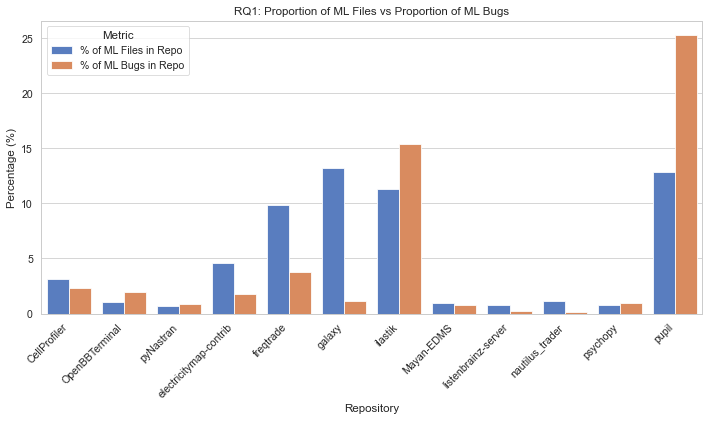

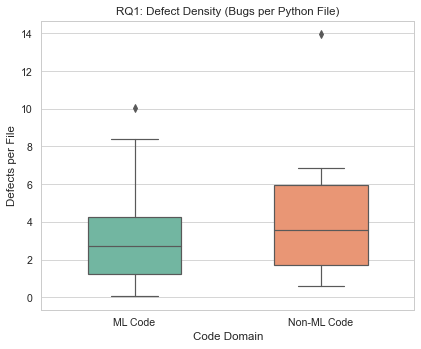

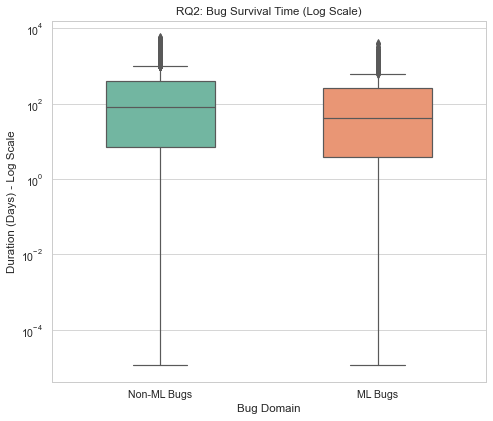

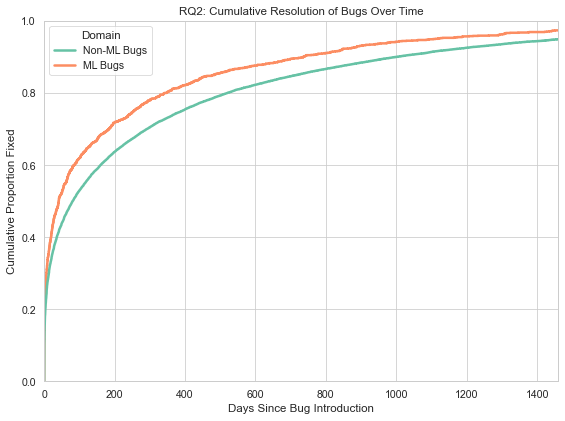

All plots generated and saved!

 EXACT VALUES FOR THE RESULTS SECTION

--- RQ1: Overall Proportions ---
Total ML Python Files: 591 out of 12385 (4.77%)
Total ML Bugs: 1256 out of 33461 (3.75%)
Average % of ML files per repo: 5.02%
Average % of ML bugs per repo:  4.55%

--- RQ1: Defect Density (Bugs per File) ---
Median ML Defect Density:     2.7336 bugs/file
Median Non-ML Defect Density: 3.5557 bugs/file
Mean ML Defect Density:       3.3814 bugs/file
Mean Non-ML Defect Density:   4.322 bugs/file

--- RQ2: Bug Survival Time Statistics (in Days) ---
               mean    50%   25%     75%
Domain                                  
ML Bugs      231.30  41.34  3.93  254.05
Non-ML Bugs  328.02  80.92  7.00  391.90

--- RQ2: Bug Resolution Milestones ---
Within 7 days:
  - ML Bugs resolved:     30.44%
  - Non-ML Bugs resolved: 25.01%
Within 30 days:
  - ML Bugs resolved:     45.99%
  - Non-ML Bugs resolved: 38.1%
Within 90 days:
  - ML Bugs resolved:     60.48%
  - Non-ML Bugs resolved: 51.36

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set publication-quality aesthetics for Seaborn
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# ==========================================
# 1. LOAD AND PREPARE THE DATA
# ==========================================
# Update these paths to where your actual CSV files are located
bugs_csv_path = "merged_ml_bug_analysis.csv"
files_csv_path = "repo_ml_file_counts.csv"

# Load data
df_bugs = pd.read_csv(bugs_csv_path)
df_files = pd.read_csv(files_csv_path)

# Calculate Bug Counts per Repository
bug_counts = df_bugs.groupby(['repo_name', 'is_ml_origin']).size().unstack(fill_value=0).reset_index()
bug_counts.columns = ['repo_name', 'non_ml_bugs', 'ml_bugs']
bug_counts['total_bugs'] = bug_counts['non_ml_bugs'] + bug_counts['ml_bugs']

# Merge with File Counts
df_merged = pd.merge(bug_counts, df_files, on='repo_name', how='inner')

# --- MODIFICATION: Extract repository name after the slash ---
# This creates a new column "repo_name_short" (e.g., "tensorflow/tensorflow" -> "tensorflow")
df_merged['repo_name_short'] = df_merged['repo_name'].str.split('/').str[-1]

# Calculate Proportions & Defect Densities
df_merged['pct_ml_files'] = (df_merged['ml_python_files'] / df_merged['total_python_files']) * 100
df_merged['pct_ml_bugs'] = (df_merged['ml_bugs'] / df_merged['total_bugs']) * 100

df_merged['ml_defect_density'] = df_merged['ml_bugs'] / df_merged['ml_python_files'].replace(0, np.nan)
df_merged['non_ml_defect_density'] = df_merged['non_ml_bugs'] / df_merged['non_ml_python_files'].replace(0, np.nan)


# ==========================================
# RQ1: BUG INTRODUCTION (ML vs Non-ML)
# ==========================================

# --- Figure 1: Proportion Bar Chart ---
plt.figure(figsize=(10, 6))

# Melt the dataframe using the NEW 'repo_name_short' column
df_melted_props = df_merged.melt(id_vars='repo_name_short', 
                                 value_vars=['pct_ml_files', 'pct_ml_bugs'],
                                 var_name='Metric', value_name='Percentage')

# Rename labels for a cleaner legend
df_melted_props['Metric'] = df_melted_props['Metric'].map({'pct_ml_files': '% of ML Files in Repo', 
                                                           'pct_ml_bugs': '% of ML Bugs in Repo'})

# Use 'repo_name_short' for the x-axis
sns.barplot(data=df_melted_props, x='repo_name_short', y='Percentage', hue='Metric', palette='muted')
plt.xticks(rotation=45, ha='right')
plt.title('RQ1: Proportion of ML Files vs Proportion of ML Bugs')
plt.ylabel('Percentage (%)')
plt.xlabel('Repository')
plt.tight_layout()
plt.savefig('RQ1_Proportions_BarChart.pdf', format='pdf', bbox_inches='tight')
plt.show()

# --- Figure 2: Defect Density Boxplot ---
plt.figure(figsize=(6, 5))

# Melt the dataframe for density
df_melted_density = df_merged.melt(id_vars='repo_name', 
                                    value_vars=['ml_defect_density', 'non_ml_defect_density'],
                                    var_name='Domain', value_name='Bugs per File')

df_melted_density['Domain'] = df_melted_density['Domain'].map({'ml_defect_density': 'ML Code', 
                                                               'non_ml_defect_density': 'Non-ML Code'})

sns.boxplot(data=df_melted_density, x='Domain', y='Bugs per File', palette='Set2', width=0.5)
plt.title('RQ1: Defect Density (Bugs per Python File)')
plt.ylabel('Defects per File')
plt.xlabel('Code Domain')
plt.tight_layout()
plt.savefig('RQ1_Defect_Density_Boxplot.pdf', format='pdf', bbox_inches='tight')
plt.show()


# ==========================================
# RQ2: BUG SURVIVAL TIME
# ==========================================
# Filter out bugs with negative or missing durations
df_duration = df_bugs[df_bugs['bug_duration_days'] > 0].copy()
df_duration['Domain'] = df_duration['is_ml_origin'].map({True: 'ML Bugs', False: 'Non-ML Bugs'})

# --- Figure 3: Log-Scaled Boxplot of Durations ---
plt.figure(figsize=(7, 6))
sns.boxplot(data=df_duration, x='Domain', y='bug_duration_days', palette='Set2', width=0.5)

# Set Y-axis to logarithmic scale (Crucial for time data)
plt.yscale('log')
plt.title('RQ2: Bug Survival Time (Log Scale)')
plt.ylabel('Duration (Days) - Log Scale')
plt.xlabel('Bug Domain')
plt.tight_layout()
plt.savefig('RQ2_Survival_Boxplot.pdf', format='pdf', bbox_inches='tight')
plt.show()

# --- Figure 4: Cumulative Distribution Function (CDF) ---
plt.figure(figsize=(8, 6))
sns.ecdfplot(data=df_duration, x='bug_duration_days', hue='Domain', palette='Set2', linewidth=2.5)

# Limit X-axis to 95th percentile so the long tail doesn't squash the visible curve
p95 = df_duration['bug_duration_days'].quantile(0.95)
plt.xlim(0, p95)

plt.title('RQ2: Cumulative Resolution of Bugs Over Time')
plt.ylabel('Cumulative Proportion Fixed')
plt.xlabel('Days Since Bug Introduction')
plt.tight_layout()
plt.savefig('RQ2_Survival_CDF.pdf', format='pdf', bbox_inches='tight')
plt.show()

print("All plots generated and saved!")

print("\n" + "="*50)
print(" EXACT VALUES FOR THE RESULTS SECTION")
print("="*50)

# ---------------------------------------------------------
# RQ1: Proportions (Corresponds to Figure 1)
# ---------------------------------------------------------
print("\n--- RQ1: Overall Proportions ---")
total_ml_files = df_merged['ml_python_files'].sum()
total_python_files = df_merged['total_python_files'].sum()
total_ml_bugs = df_merged['ml_bugs'].sum()
total_bugs = df_merged['total_bugs'].sum()

print(f"Total ML Python Files: {total_ml_files} out of {total_python_files} ({round((total_ml_files/total_python_files)*100, 2)}%)")
print(f"Total ML Bugs: {total_ml_bugs} out of {total_bugs} ({round((total_ml_bugs/total_bugs)*100, 2)}%)")
print(f"Average % of ML files per repo: {round(df_merged['pct_ml_files'].mean(), 2)}%")
print(f"Average % of ML bugs per repo:  {round(df_merged['pct_ml_bugs'].mean(), 2)}%")

# ---------------------------------------------------------
# RQ1: Defect Density (Corresponds to Figure 2)
# ---------------------------------------------------------
print("\n--- RQ1: Defect Density (Bugs per File) ---")
print(f"Median ML Defect Density:     {round(df_merged['ml_defect_density'].median(), 4)} bugs/file")
print(f"Median Non-ML Defect Density: {round(df_merged['non_ml_defect_density'].median(), 4)} bugs/file")
print(f"Mean ML Defect Density:       {round(df_merged['ml_defect_density'].mean(), 4)} bugs/file")
print(f"Mean Non-ML Defect Density:   {round(df_merged['non_ml_defect_density'].mean(), 4)} bugs/file")

# ---------------------------------------------------------
# RQ2: Survival Time (Corresponds to Figure 3)
# ---------------------------------------------------------
print("\n--- RQ2: Bug Survival Time Statistics (in Days) ---")
# describe() gives us the mean, median (50%), and interquartile ranges (25%, 75%)
survival_stats = df_duration.groupby('Domain')['bug_duration_days'].describe()
# Select only the relevant columns and round to 2 decimal places
print(survival_stats[['mean', '50%', '25%', '75%']].round(2).to_string())

# ---------------------------------------------------------
# RQ2: CDF Milestones (Corresponds to Figure 4)
# ---------------------------------------------------------
print("\n--- RQ2: Bug Resolution Milestones ---")
# How many bugs are fixed within a standard sprint (7 days), a month (30 days), or a quarter (90 days)?
milestones = [7, 30, 90]

for days in milestones:
    ml_fixed = len(df_duration[(df_duration['Domain'] == 'ML Bugs') & (df_duration['bug_duration_days'] <= days)])
    total_ml_duration = len(df_duration[df_duration['Domain'] == 'ML Bugs'])
    
    non_ml_fixed = len(df_duration[(df_duration['Domain'] == 'Non-ML Bugs') & (df_duration['bug_duration_days'] <= days)])
    total_non_ml_duration = len(df_duration[df_duration['Domain'] == 'Non-ML Bugs'])
    
    print(f"Within {days} days:")
    print(f"  - ML Bugs resolved:     {round((ml_fixed/total_ml_duration)*100, 2)}%")
    print(f"  - Non-ML Bugs resolved: {round((non_ml_fixed/total_non_ml_duration)*100, 2)}%")

In [9]:
import pandas as pd
import numpy as np

# Assuming df_merged and df_duration are already in memory from the previous script

# ==========================================
# 1. CALCULATE STATUS CATEGORIES
# ==========================================

# A. Calculate 'ML Defect Risk Status'
# Risk Factor = (% of ML Bugs) / (% of ML Files)
# E.g., If ML files are 5% of the repo, but cause 15% of bugs, Risk = 3.0
df_merged['Risk_Factor'] = df_merged['pct_ml_bugs'] / df_merged['pct_ml_files'].replace(0, np.nan)

def assign_risk_status(risk):
    if pd.isna(risk): return "N/A"
    elif risk > 1.5: return "High Risk"          # Punching significantly above their weight
    elif risk > 1.0: return "Disproportionate"   # Slightly higher than expected
    else: return "Nominal"                       # Matching or lower than expected footprint

df_merged['ML_Risk_Status'] = df_merged['Risk_Factor'].apply(assign_risk_status)

# B. Calculate 'Median ML Bug Lifespan' and 'Resolution Category' per repo
ml_durations = df_duration[df_duration['Domain'] == 'ML Bugs']
median_durations = ml_durations.groupby('repo_name')['bug_duration_days'].median().reset_index()
median_durations.rename(columns={'bug_duration_days': 'Median_ML_Lifespan'}, inplace=True)

def assign_resolution_category(days):
    if pd.isna(days): return "N/A"
    elif days <= 7: return "Swift Fix"
    elif days <= 30: return "Standard"
    elif days <= 90: return "Prolonged"
    else: return "Dormant"

median_durations['ML_Resolution_Category'] = median_durations['Median_ML_Lifespan'].apply(assign_resolution_category)

# ==========================================
# 2. BUILD THE FINAL TABLE
# ==========================================

# Merge the statuses back together
df_table = pd.merge(df_merged, median_durations, on='repo_name', how='left')

# Select and order the columns for the academic paper
table_presentation = df_table[[
    'repo_name', 
    'total_python_files', 
    'pct_ml_files', 
    'total_bugs', 
    'pct_ml_bugs', 
    'ML_Risk_Status', 
    'ML_Resolution_Category'
]].copy()

# Format the numeric columns beautifully for the paper
table_presentation['pct_ml_files'] = table_presentation['pct_ml_files'].apply(lambda x: f"{x:.1f}\\%" if pd.notna(x) else "0.0\\%")
table_presentation['pct_ml_bugs'] = table_presentation['pct_ml_bugs'].apply(lambda x: f"{x:.1f}\\%" if pd.notna(x) else "0.0\\%")
table_presentation['total_python_files'] = table_presentation['total_python_files'].apply(lambda x: f"{int(x):,}")
table_presentation['total_bugs'] = table_presentation['total_bugs'].apply(lambda x: f"{int(x):,}")

# Rename columns to their final LaTeX headers
table_presentation.columns = [
    'Repository', 
    'Python Files', 
    'ML Files (\\%)', 
    'Total Bugs', 
    'ML Bugs (\\%)', 
    'ML Risk Status', 
    'Avg. Resolution'
]

# ==========================================
# 3. EXPORT TO LATEX
# ==========================================
print("\n--- LATEX TABLE OUTPUT ---\n")

# Use booktabs=True for standard IEEE/ACM toprule/midrule/bottomrule formatting
latex_table = table_presentation.to_latex(
    index=False, 
    column_format='lrrrrll', # Left, Right, Right, Right, Right, Left, Left alignment
    caption='Overview of Subject Projects, Defect Proportions, and ML Risk Statuses.',
    label='tab:subject_projects',
    position='htbp'
)

# A small string replacement to ensure booktabs is used correctly in newer pandas versions
latex_table = latex_table.replace('\\toprule', '\\toprule\n').replace('\\midrule', '\\midrule\n').replace('\\bottomrule', '\\bottomrule\n')

print(latex_table)


--- LATEX TABLE OUTPUT ---

\begin{table}[htbp]
\centering
\caption{Overview of Subject Projects, Defect Proportions, and ML Risk Statuses.}
\label{tab:subject_projects}
\begin{tabular}{lrrrrll}
\toprule

                           Repository & Python Files & ML Files (\textbackslash \%) & Total Bugs & ML Bugs (\textbackslash \%) &   ML Risk Status & Avg. Resolution \\
\midrule

            CellProfiler/CellProfiler &          859 &         3.1\textbackslash \% &      3,366 &        2.3\textbackslash \% &          Nominal &         Dormant \\
        OpenBB-finance/OpenBBTerminal &        1,268 &         1.0\textbackslash \% &      2,509 &        2.0\textbackslash \% &        High Risk &        Standard \\
                SteveDoyle2/pyNastran &        1,533 &         0.7\textbackslash \% &      1,560 &        0.9\textbackslash \% & Disproportionate &         Dormant \\
electricitymap/electricitymap-contrib &          286 &         4.5\textbackslash \% &      1,904 &        1.8\textba

C:\Users\user\AppData\Local\Temp/ipykernel_16040/1874967638.py:78: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_table = table_presentation.to_latex(
